# Experiment 1 – Simple Linear Regression

Build a Linear Regression model to predict **Sales** using **TV advertising budget**.  
The dataset is loaded, visualized, and split into training and testing sets (80:20).  
The model is trained and evaluated using **RMSE and R² score**.

First 5 rows of dataset:
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None


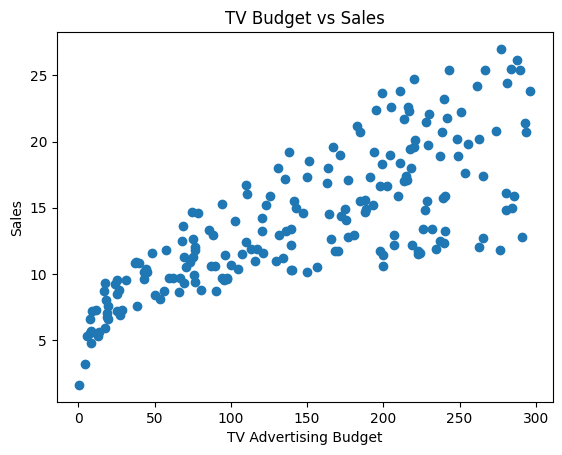


Training data shape: (160, 1)
Testing data shape: (40, 1)

Model Parameters:
Intercept (b0): 7.119638430592953
Coefficient (b1): [0.04652973]


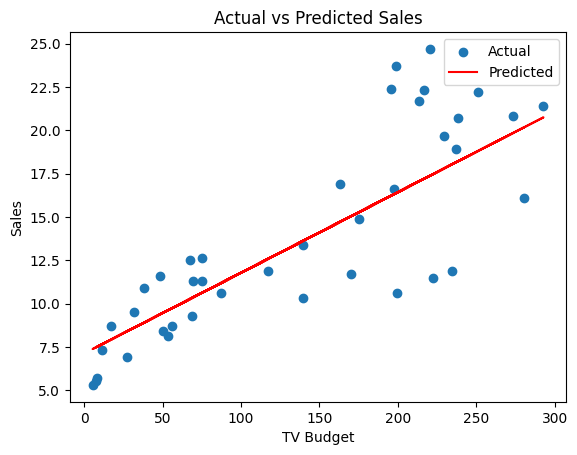


RMSE: 3.194472431998898
R² Score: 0.6766954295627076


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("TvMarketing.csv")

print("First 5 rows of dataset:")
print(df.head())
print("\nDataset Information:")
print(df.info())

# Visualize relationship
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

# Prepare data
X = df[["TV"]]
y = df["Sales"]

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Parameters:")
print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_)

# Predictions
y_pred = model.predict(X_test)

# Actual vs Predicted
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted")
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRMSE:", rmse)
print("R² Score:", r2)